In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import joblib

df = pd.read_csv("cleaned_data.csv")

# Features and target
X = df.drop("Patv", axis=1)
y = df["Patv"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load saved model
rf = joblib.load("models/wind_model.pkl")

print("Everything loaded ✅")
print("Features:", X.columns.tolist())

Everything loaded ✅
Features: ['Wspd', 'Wdir', 'Etmp', 'Itmp', 'Ndir', 'Pab1', 'Pab2', 'Pab3', 'Prtv', 'yaw_error']


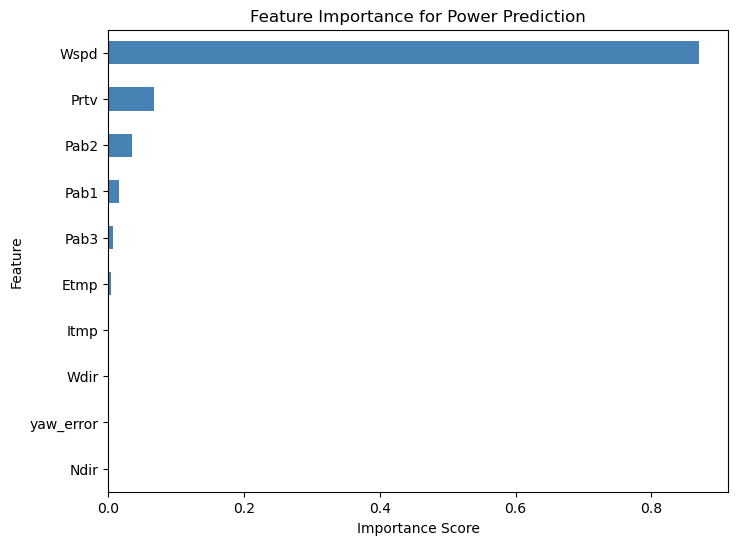

In [ ]:

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

importance.plot(kind="barh", x="Feature", y="Importance",
                figsize=(8, 6), legend=False, color="steelblue")
plt.title("Feature Importance for Power Prediction")
plt.xlabel("Importance Score")
plt.savefig("04_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

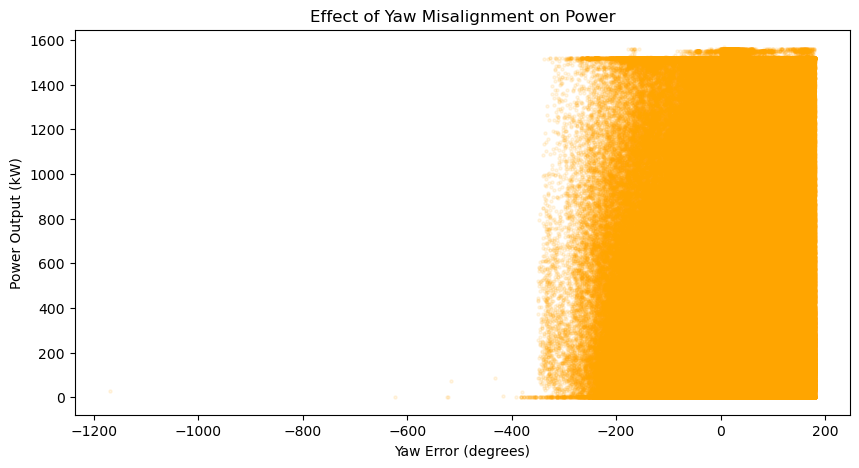

In [3]:
plt.figure(figsize=(10, 5))
plt.scatter(df["yaw_error"], df["Patv"], alpha=0.1, s=5, color="orange")
plt.xlabel("Yaw Error (degrees)")
plt.ylabel("Power Output (kW)")
plt.title("Effect of Yaw Misalignment on Power")
plt.savefig("04_yaw_error.png", dpi=150, bbox_inches='tight')
plt.show()